In [16]:
import sys
import os
# Add the project root to Python path (assuming we're in tests/tests_mcts/)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.algos.mcts import evaluate
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

def run_symmetry_comparison_experiment():
    """
    Experiment to compare how different max_level_to_use_symmetry values affect running time
    """
    # Fixed parameters for the experiment
    n = 10  # Grid size
    num_trials = 10  # Number of trials per symmetry level for averaging
    
    # Different symmetry levels to test
    symmetry_levels = [-1, 0, 1, 2, 3, 4, 5, 10]  # 0 = no symmetry, higher = more symmetry usage
    
    results = []
    
    print(f"Starting symmetry comparison experiment for n={n}")
    print(f"Testing symmetry levels: {symmetry_levels}")
    print(f"Number of trials per level: {num_trials}")
    print("=" * 60)
    
    for max_symmetry in symmetry_levels:
        print(f"\nTesting max_level_to_use_symmetry = {max_symmetry}")
        
        trial_times = []
        trial_points = []
        
        for trial in range(num_trials):
            print(f"  Trial {trial + 1}/{num_trials}...", end=" ")
            
            args = {
                'environment': 'N3il_with_symmetry',
                'algorithm': 'MCTS',
                'max_level_to_use_symmetry': max_symmetry,
                'n': n,
                'C': 1.41,
                'num_searches': 50*(n**2),  # Reduced for faster experiments
                'num_workers': 1,  # Reduced for more controlled timing
                'virtual_loss': 1.0,
                'process_bar': False,  # Disable progress bar for cleaner output
                'display_state': False,  # Disable state display for cleaner output
                'logging_mode': True,  # Enable to get return value
                'TopN': n,
                "simulate_with_priority": False,
                'table_dir': f'tests/tests_mcts',
                'figure_dir': f'tests/tests_mcts/figure',
                'random_seed': trial + (max_symmetry+1) * 100,  # Ensure different seeds
            }
            
            # Measure execution time
            start_time = time.time()
            num_points = evaluate(args)
            end_time = time.time()
            
            execution_time = end_time - start_time
            trial_times.append(execution_time)
            trial_points.append(num_points)
            
            print(f"Time: {execution_time:.2f}s, Points: {num_points}")
        
        # Calculate statistics for this symmetry level
        avg_time = np.mean(trial_times)
        std_time = np.std(trial_times)
        avg_points = np.mean(trial_points)
        
        results.append({
            'max_symmetry': max_symmetry,
            'avg_time': avg_time,
            'std_time': std_time,
            'avg_points': avg_points,
            'trial_times': trial_times,
            'trial_points': trial_points
        })
        
        print(f"  Average time: {avg_time:.2f}±{std_time:.2f}s")
        print(f"  Average points: {avg_points:.1f}")
    
    return results

# Run the experiment
experiment_results = run_symmetry_comparison_experiment()

Starting symmetry comparison experiment for n=10
Testing symmetry levels: [-1, 0, 1, 2, 3, 4, 5, 10]
Number of trials per level: 10

Testing max_level_to_use_symmetry = -1
  Trial 1/10... *******************************************************************
Trial Terminated with 18 points. Final valid configuration:
[[0 0 0 0 0 1 0 0 0 1]
 [0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 1 0]
 [0 0 0 0 0 0 0 0 0 1]
 [1 0 1 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 1 0 0 0]
 [0 1 0 0 0 0 0 0 1 0]
 [1 0 0 0 0 0 1 0 0 0]
 [0 0 0 1 0 0 0 1 0 0]
 [0 1 0 0 0 1 0 0 0 0]]
Plot saved as: tests/tests_mcts/figure/20250805_105103_10by10/no_three_in_line_10x10_pts18_MCTS_20250805_105103.png (DPI: 150)
Time: 2.162584 sec
Results recorded to: tests/tests_mcts/experiment_results.csv
Time: 2.17s, Points: 18
  Trial 2/10... *******************************************************************
Trial Terminated with 20 points. Final valid configuration:
[[0 0 0 0 0 1 1 0 0 0]
 [0 0 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 1]
 [1 0 1 0

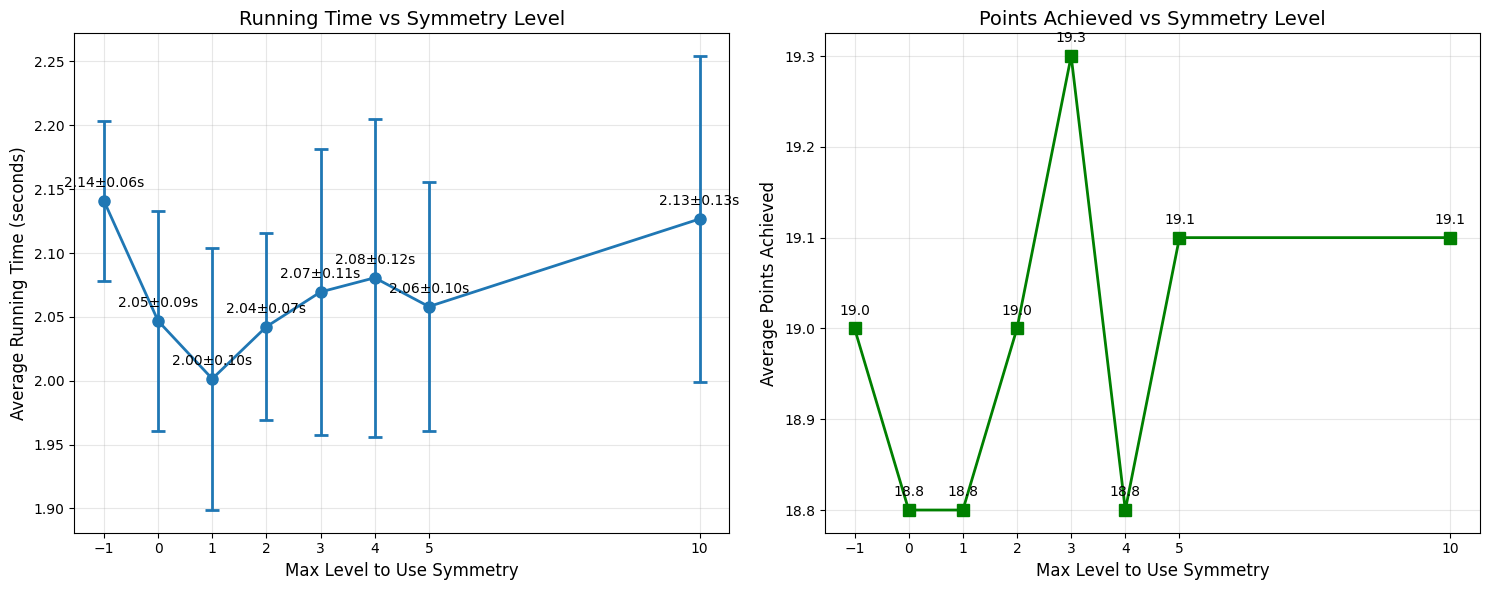


DETAILED RESULTS SUMMARY
 Symmetry Level Avg Time (s) Std Time (s) Avg Points Time vs No-Symmetry
             -1         2.14         0.06       19.0               1.00x
              0         2.05         0.09       18.8               0.96x
              1         2.00         0.10       18.8               0.93x
              2         2.04         0.07       19.0               0.95x
              3         2.07         0.11       19.3               0.97x
              4         2.08         0.12       18.8               0.97x
              5         2.06         0.10       19.1               0.96x
             10         2.13         0.13       19.1               0.99x

ANALYSIS INSIGHTS
• Baseline (no symmetry): 2.14s
• Fastest configuration: max_symmetry=1 at 2.00s
• Speed improvement: 1.07x faster
• Time reduction: 6.5%
• Point consistency: High (std=0.17) - symmetry doesn't affect solution quality


In [18]:
# Plot the results
def plot_symmetry_results(results):
    """
    Plot the results of the symmetry comparison experiment
    """
    # Extract data for plotting
    symmetry_levels = [r['max_symmetry'] for r in results]
    avg_times = [r['avg_time'] for r in results]
    std_times = [r['std_time'] for r in results]
    avg_points = [r['avg_points'] for r in results]
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Running time vs symmetry level
    ax1.errorbar(symmetry_levels, avg_times, yerr=std_times, 
                marker='o', capsize=5, capthick=2, linewidth=2, markersize=8)
    ax1.set_xlabel('Max Level to Use Symmetry', fontsize=12)
    ax1.set_ylabel('Average Running Time (seconds)', fontsize=12)
    ax1.set_title('Running Time vs Symmetry Level', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(symmetry_levels)
    
    # Add value labels on points
    for i, (x, y, err) in enumerate(zip(symmetry_levels, avg_times, std_times)):
        ax1.annotate(f'{y:.2f}±{err:.2f}s', 
                    (x, y), textcoords="offset points", 
                    xytext=(0,10), ha='center', fontsize=10)
    
    # Plot 2: Average points achieved vs symmetry level
    ax2.plot(symmetry_levels, avg_points, marker='s', linewidth=2, markersize=8, color='green')
    ax2.set_xlabel('Max Level to Use Symmetry', fontsize=12)
    ax2.set_ylabel('Average Points Achieved', fontsize=12)
    ax2.set_title('Points Achieved vs Symmetry Level', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(symmetry_levels)
    
    # Add value labels on points
    for i, (x, y) in enumerate(zip(symmetry_levels, avg_points)):
        ax2.annotate(f'{y:.1f}', 
                    (x, y), textcoords="offset points", 
                    xytext=(0,10), ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('tests/tests_mcts/figure/symmetry_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create detailed results table
    print("\n" + "="*80)
    print("DETAILED RESULTS SUMMARY")
    print("="*80)
    
    df_results = pd.DataFrame({
        'Symmetry Level': symmetry_levels,
        'Avg Time (s)': [f'{t:.2f}' for t in avg_times],
        'Std Time (s)': [f'{t:.2f}' for t in std_times],
        'Avg Points': [f'{p:.1f}' for p in avg_points],
        'Time vs No-Symmetry': [f'{t/avg_times[0]:.2f}x' for t in avg_times]
    })
    
    print(df_results.to_string(index=False))
    
    # Calculate and display insights
    print(f"\n" + "="*80)
    print("ANALYSIS INSIGHTS")
    print("="*80)
    
    baseline_time = avg_times[0]  # No symmetry case
    min_time_idx = np.argmin(avg_times)
    min_time = avg_times[min_time_idx]
    best_symmetry = symmetry_levels[min_time_idx]
    
    print(f"• Baseline (no symmetry): {baseline_time:.2f}s")
    print(f"• Fastest configuration: max_symmetry={best_symmetry} at {min_time:.2f}s")
    print(f"• Speed improvement: {baseline_time/min_time:.2f}x faster")
    print(f"• Time reduction: {((baseline_time-min_time)/baseline_time)*100:.1f}%")
    
    # Points analysis
    points_std = np.std(avg_points)
    if points_std < 1.0:
        print(f"• Point consistency: High (std={points_std:.2f}) - symmetry doesn't affect solution quality")
    else:
        print(f"• Point consistency: Variable (std={points_std:.2f}) - some impact on solution quality")

# Plot the results
plot_symmetry_results(experiment_results)

In [20]:
# Optional: Plot individual trial data for more detailed analysis
def plot_individual_trials(results):
    """
    Plot individual trial data to show variability
    """
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Plot individual trials as scatter points
    for i, result in enumerate(results):
        symmetry_level = result['max_symmetry']
        trial_times = result['trial_times']
        
        # Add some jitter for better visualization
        x_positions = [symmetry_level + np.random.normal(0, 0.1) for _ in trial_times]
        ax.scatter(x_positions, trial_times, alpha=0.6, s=50, label=f'Level {symmetry_level}')
    
    # Plot averages as a line
    symmetry_levels = [r['max_symmetry'] for r in results]
    avg_times = [r['avg_time'] for r in results]
    ax.plot(symmetry_levels, avg_times, 'k-', linewidth=3, marker='D', 
            markersize=10, label='Average', zorder=10)
    
    ax.set_xlabel('Max Level to Use Symmetry', fontsize=12)
    ax.set_ylabel('Running Time (seconds)', fontsize=12)
    ax.set_title('Individual Trial Results: Running Time vs Symmetry Level', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(symmetry_levels)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.savefig('tests/tests_mcts/figure/symmetry_individual_trials.png', dpi=300, bbox_inches='tight')
    plt.show()

# Uncomment the line below to see individual trial variability
# plot_individual_trials(experiment_results)

In [21]:
# Statistical Analysis: T-test comparing Symmetry Level 1 vs No-Symmetry (-1)
from scipy import stats
import numpy as np

def perform_symmetry_ttest(results):
    """
    Perform a t-test to compare running times between symmetry level 1 and no-symmetry (-1)
    """
    # Extract data for symmetry levels -1 and 1
    no_symmetry_data = None
    symmetry_1_data = None
    
    for result in results:
        if result['max_symmetry'] == -1:
            no_symmetry_data = result['trial_times']
        elif result['max_symmetry'] == 1:
            symmetry_1_data = result['trial_times']
    
    if no_symmetry_data is None or symmetry_1_data is None:
        print("Error: Could not find data for symmetry levels -1 and 1")
        return
    
    print("="*80)
    print("STATISTICAL ANALYSIS: T-TEST COMPARISON")
    print("="*80)
    print("Hypothesis Test: Is symmetry level 1 significantly faster than no-symmetry (-1)?")
    print()
    
    # Convert to numpy arrays
    no_sym_times = np.array(no_symmetry_data)
    sym1_times = np.array(symmetry_1_data)
    
    # Descriptive statistics
    print("DESCRIPTIVE STATISTICS:")
    print("-" * 40)
    print(f"No-Symmetry (level -1):")
    print(f"  Sample size: {len(no_sym_times)}")
    print(f"  Mean: {np.mean(no_sym_times):.3f} seconds")
    print(f"  Std Dev: {np.std(no_sym_times, ddof=1):.3f} seconds")
    print(f"  Min: {np.min(no_sym_times):.3f} seconds")
    print(f"  Max: {np.max(no_sym_times):.3f} seconds")
    print()
    
    print(f"Symmetry Level 1:")
    print(f"  Sample size: {len(sym1_times)}")
    print(f"  Mean: {np.mean(sym1_times):.3f} seconds")
    print(f"  Std Dev: {np.std(sym1_times, ddof=1):.3f} seconds")
    print(f"  Min: {np.min(sym1_times):.3f} seconds")
    print(f"  Max: {np.max(sym1_times):.3f} seconds")
    print()
    
    # Calculate difference
    mean_diff = np.mean(no_sym_times) - np.mean(sym1_times)
    percent_improvement = (mean_diff / np.mean(no_sym_times)) * 100
    
    print(f"Mean difference: {mean_diff:.3f} seconds")
    print(f"Percent improvement: {percent_improvement:.1f}%")
    print()
    
    # Perform two-sample t-test
    # H0: mean(no_symmetry) <= mean(symmetry_1) (symmetry is not better)
    # H1: mean(no_symmetry) > mean(symmetry_1) (symmetry is better - one-tailed test)
    
    # First, check if we should use equal or unequal variances
    # Levene's test for equal variances
    levene_stat, levene_p = stats.levene(no_sym_times, sym1_times)
    equal_var = levene_p > 0.05  # If p > 0.05, assume equal variances
    
    print("STATISTICAL TEST RESULTS:")
    print("-" * 40)
    print(f"Levene's test for equal variances: p = {levene_p:.4f}")
    print(f"Assumption: {'Equal variances' if equal_var else 'Unequal variances'}")
    print()
    
    # Perform two-sample t-test (one-tailed)
    t_stat, p_value_two_tailed = stats.ttest_ind(no_sym_times, sym1_times, equal_var=equal_var)
    
    # Convert to one-tailed test (we want to test if no_symmetry > symmetry_1)
    if t_stat > 0:  # no_symmetry has higher mean (which is what we expect)
        p_value_one_tailed = p_value_two_tailed / 2
    else:  # symmetry_1 has higher mean (opposite of what we expect)
        p_value_one_tailed = 1 - (p_value_two_tailed / 2)
    
    print("T-TEST RESULTS:")
    print(f"t-statistic: {t_stat:.4f}")
    print(f"p-value (one-tailed): {p_value_one_tailed:.4f}")
    print(f"p-value (two-tailed): {p_value_two_tailed:.4f}")
    print()
    
    # Effect size (Cohen's d)
    pooled_std = np.sqrt(((len(no_sym_times)-1)*np.var(no_sym_times, ddof=1) + 
                         (len(sym1_times)-1)*np.var(sym1_times, ddof=1)) / 
                        (len(no_sym_times) + len(sym1_times) - 2))
    cohens_d = mean_diff / pooled_std
    
    print(f"Effect size (Cohen's d): {cohens_d:.4f}")
    
    # Interpret effect size
    if abs(cohens_d) < 0.2:
        effect_interpretation = "negligible"
    elif abs(cohens_d) < 0.5:
        effect_interpretation = "small"
    elif abs(cohens_d) < 0.8:
        effect_interpretation = "medium"
    else:
        effect_interpretation = "large"
    
    print(f"Effect size interpretation: {effect_interpretation}")
    print()
    
    # Statistical conclusions
    print("CONCLUSIONS:")
    print("-" * 40)
    alpha = 0.05
    
    if p_value_one_tailed < alpha:
        print(f"✓ SIGNIFICANT: p = {p_value_one_tailed:.4f} < α = {alpha}")
        print("  We have sufficient evidence to conclude that symmetry level 1")
        print("  is significantly faster than no-symmetry (level -1).")
    else:
        print(f"✗ NOT SIGNIFICANT: p = {p_value_one_tailed:.4f} ≥ α = {alpha}")
        print("  We do not have sufficient evidence to conclude that symmetry level 1")
        print("  is significantly faster than no-symmetry (level -1).")
    
    print()
    print(f"Practical significance: {percent_improvement:.1f}% speed improvement")
    print(f"Effect size: {effect_interpretation} ({cohens_d:.3f})")
    
    # Confidence interval for the difference
    se_diff = np.sqrt(np.var(no_sym_times, ddof=1)/len(no_sym_times) + 
                     np.var(sym1_times, ddof=1)/len(sym1_times))
    df = len(no_sym_times) + len(sym1_times) - 2
    t_critical = stats.t.ppf(0.975, df)  # 95% CI
    ci_lower = mean_diff - t_critical * se_diff
    ci_upper = mean_diff + t_critical * se_diff
    
    print(f"95% Confidence Interval for difference: [{ci_lower:.3f}, {ci_upper:.3f}] seconds")
    print("="*80)

# Perform the statistical analysis
perform_symmetry_ttest(experiment_results)

ModuleNotFoundError: No module named 'scipy'

In [ ]:
!conda install scipy